# Python and Math Primer

Welcome to Computational Chemistry! Before we dive into quantum mechanics and molecular dynamics, we need to ensure our basic computational tools are sharp. In this course, Python is our laboratory. 

Today, we will review:
1. **Vectorization with NumPy:** How to do math on arrays quickly.
2. **Plotting with Matplotlib:** Visualizing chemical data.
3. **Coordinate Math:** Calculating atomic distances from 3D space.

In [9]:
#| code-fold: true
#| code-summary: "Click to see the library imports for this chapter"

import numpy as np
import matplotlib.pyplot as plt

# Make our plots look professional
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Storing Data: Lists and Indexing

Before we do heavy math, we need to know how Python stores information. Imagine you have a rack of test tubes. In Python, the equivalent of this rack is called a **List** (or an Array). It is simply an ordered collection of items.



Crucially, computers start counting at **zero**. So, the first "test tube" is at position 0, the second is at position 1, and so on. This position is called the **index**.

Let's look at a list of atomic masses for the first few noble gases: Helium, Neon, and Argon.

In [10]:
# A standard Python list uses square brackets
noble_gas_masses = [4.00, 20.18, 39.95]

print("Our entire list of masses:", noble_gas_masses)

# To look at a specific item, we use its index in square brackets
first_mass = noble_gas_masses[0]
print("The mass of Helium (index 0) is:", first_mass)

second_mass = noble_gas_masses[1]
print("The mass of Neon (index 1) is:", second_mass)

Our entire list of masses: [4.0, 20.18, 39.95]
The mass of Helium (index 0) is: 4.0
The mass of Neon (index 1) is: 20.18


### Why do we need NumPy Arrays?

Standard Python lists are great for holding stuff, but they are terrible at math. If you try to multiply a standard Python list by 2, it doesn't double the numbers; it just duplicates the list! 

Because computational chemistry requires doing math on thousands of numbers at once, we use a library called **NumPy**. A NumPy array looks just like a list, but it acts like a mathematical vector.

In [11]:
# Let's see the difference between a List and a NumPy Array
my_list = [1.0, 2.0, 3.0]
my_array = np.array([1.0, 2.0, 3.0])

print("List * 2 gives:  ", my_list * 2)
print("Array * 2 gives: ", my_array * 2)

List * 2 gives:   [1.0, 2.0, 3.0, 1.0, 2.0, 3.0]
Array * 2 gives:  [2. 4. 6.]


## Vectorization and Visualization

In computational chemistry, we rarely calculate a single value. We calculate properties over a grid of points or thousands of atoms. `numpy` allows us to apply mathematical operations to entire arrays at once (vectorization), which is orders of magnitude faster than using a standard Python `for` loop.

To see this in action, let's plot the **Lennard-Jones potential**, which approximates the interaction between two neutral atoms (like Argon). The potential energy $V(r)$ as a function of the distance $r$ is given by:

$$V(r) = 4\epsilon \left[ \left(\frac{\sigma}{r}\right)^{12} - \left(\frac{\sigma}{r}\right)^6 \right]$$

Where:
* $\epsilon$ is the depth of the potential well.
* $\sigma$ is the distance at which the potential is zero.

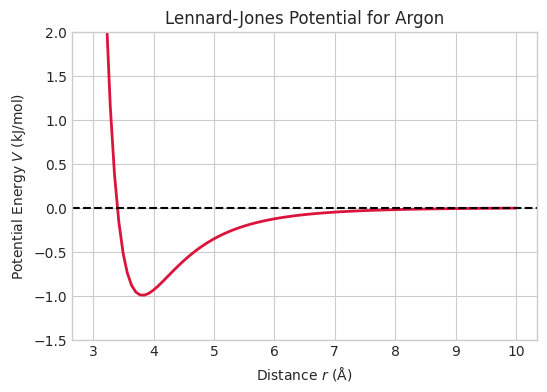

In [7]:
# Define parameters for Argon
epsilon = 0.997 # kJ/mol
sigma = 3.40 # Angstroms

# Create an array of distances from 3.0 to 10.0 Angstroms
# We use numpy arrays so we can do math on all 100 points simultaneously!
r = np.linspace(3.0, 10.0, 100)

# Calculate the potential (notice how the formula looks almost identical to the math equation)
V = 4 * epsilon * ((sigma / r)**12 - (sigma / r)**6)

# Plotting
plt.figure(figsize=(6, 4))
plt.plot(r, V, color='crimson', linewidth=2)
plt.axhline(0, color='black', linestyle='--') # Add a line at Energy = 0
plt.xlabel('Distance $r$ (Å)')
plt.ylabel('Potential Energy $V$ (kJ/mol)')
plt.title('Lennard-Jones Potential for Argon')
plt.ylim(-1.5, 2.0)
plt.show()

## Working with 3D Coordinates

A massive part of computational chemistry is simply managing where atoms are in 3D space. The standard Euclidean distance $d$ between two atoms at coordinates $(x_1, y_1, z_1)$ and $(x_2, y_2, z_2)$ is:

$$d = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2 + (z_2 - z_1)^2}$$

Using `numpy`, we can calculate this without writing out the individual $x, y, z$ components. We can use the linear algebra norm `np.linalg.norm()`.

In [12]:
# Coordinates of a water molecule (Oxygen at the origin)
# Format: np.array([x, y, z]) in Angstroms
oxygen = np.array([0.000, 0.000, 0.119])
hydrogen_1 = np.array([0.000, 0.763, -0.477])
hydrogen_2 = np.array([0.000, -0.763, -0.477])

# Calculate the O-H bond length
bond_vector = hydrogen_1 - oxygen
bond_length = np.linalg.norm(bond_vector)

print(f"The O-H bond length is {bond_length:.3f} Å")

# Calculate the H-H distance
hh_vector = hydrogen_1 - hydrogen_2
hh_distance = np.linalg.norm(hh_vector)

print(f"The H-H distance is {hh_distance:.3f} Å")

The O-H bond length is 0.968 Å
The H-H distance is 1.526 Å
